# Лабораторная работа №1: Логистическая регрессия
# Прогнозирование оттока клиентов банка

# 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Библиотеки импортированы")

Библиотеки импортированы


# 2. Генерация синтетических данных для банковского оттока

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 10000

# Генерация признаков
data = {
    'RowNumber': np.arange(1, n_samples + 1),
    'CustomerId': np.random.randint(15565701, 15856204, n_samples),
    'Surname': ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Rodriguez', 'Martinez'] * 1000,
    'CreditScore': np.random.randint(350, 851, n_samples),
    'Geography': np.random.choice(['France', 'Spain', 'Germany'], n_samples, p=[0.50, 0.25, 0.25]),
    'Gender': np.random.choice(['Female', 'Male'], n_samples, p=[0.45, 0.55]),
    'Age': np.random.normal(39, 10, n_samples).astype(int).clip(18, 92),
    'Tenure': np.random.randint(0, 11, n_samples),
    'Balance': np.random.choice([0] * 3000 + list(np.random.uniform(0, 250000, 7000)), n_samples),
    'NumOfProducts': np.random.choice([1, 2, 3, 4], n_samples, p=[0.6, 0.25, 0.10, 0.05]),
    'HasCrCard': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'IsActiveMember': np.random.choice([0, 1], n_samples, p=[0.48, 0.52]),
    'EstimatedSalary': np.random.uniform(10, 200000, n_samples)
}

df = pd.DataFrame(data)

# Генерация целевой переменной на основе признаков
def generate_exited(row):
    score = 0
    score += (row['Age'] - 30) * 0.03
    score += (row['CreditScore'] - 600) * -0.005
    score += (row['Balance'] / 100000) * 0.2
    score += (row['NumOfProducts'] - 1) * 0.15
    score += (row['IsActiveMember'] == 0) * 0.3
    score += (row['Geography'] == 'Germany') * 0.2
    score += (row['Gender'] == 'Male') * 0.1
    score += (row['Tenure'] - 5) * -0.02
    score += np.random.normal(0, 0.3)
    prob = 1 / (1 + np.exp(-score))
    return int(np.random.rand() < prob)

df['Exited'] = df.apply(generate_exited, axis=1)

# Сохранение в CSV
df.to_csv('Churn_Modelling.csv', index=False)

print("✅ Синтетические данные созданы и сохранены в Churn_Modelling.csv")
print(f"📊 Размер данных: {df.shape}")
print(f"📋 Ушедшие клиенты: {df['Exited'].sum()} ({df['Exited'].mean()*100:.1f}%)")
print("\nПервые 5 строк:")
print(df.head())

✅ Синтетические данные созданы и сохранены в Churn_Modelling.csv
📊 Размер данных: (10000, 14)
📋 Ушедшие клиенты: 6675 (66.8%)

Первые 5 строк:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15687659     Smith          517    France    Male   26   
1          2    15712568   Johnson          746     Spain    Male   42   
2          3    15697633  Williams          529    France    Male   41   
3          4    15824879     Brown          407   Germany  Female   52   
4          5    15685580     Jones          829    France    Male   43   

   Tenure        Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       4   40321.383762              1          1               1   
1       0       0.000000              1          0               0   
2       8       0.000000              2          0               0   
3      10  110676.536738              3          0               1   
4      10  187533.531571              1          1            

# 3. Анализ целевой переменной


Распределение целевой переменной:
Exited
1    6675
0    3325
Name: count, dtype: int64

Доля ушедших: 66.75%
Доля лояльных: 33.25%


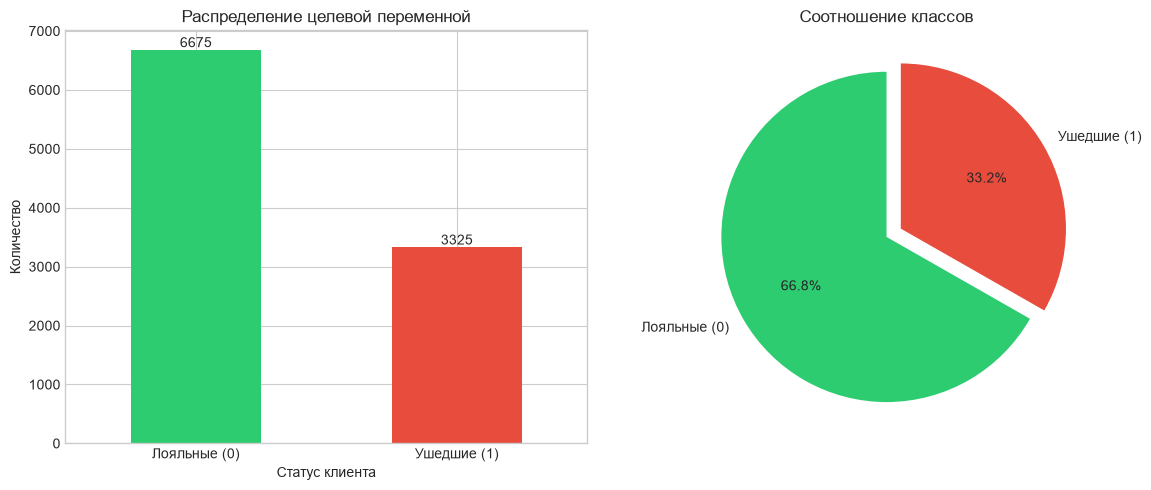

In [3]:
print("\nРаспределение целевой переменной:")
print(df['Exited'].value_counts())
print(f"\nДоля ушедших: {df['Exited'].mean()*100:.2f}%")
print(f"Доля лояльных: {(1-df['Exited'].mean())*100:.2f}%")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
labels = ['Лояльные (0)', 'Ушедшие (1)']

df['Exited'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Статус клиента')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(labels, rotation=0)

for i, v in enumerate(df['Exited'].value_counts().values):
    axes[0].text(i, v + 50, str(v), ha='center')

axes[1].pie(df['Exited'].value_counts(), labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Соотношение классов')

plt.tight_layout()
plt.show()


# 4. Анализ категориальных признаков

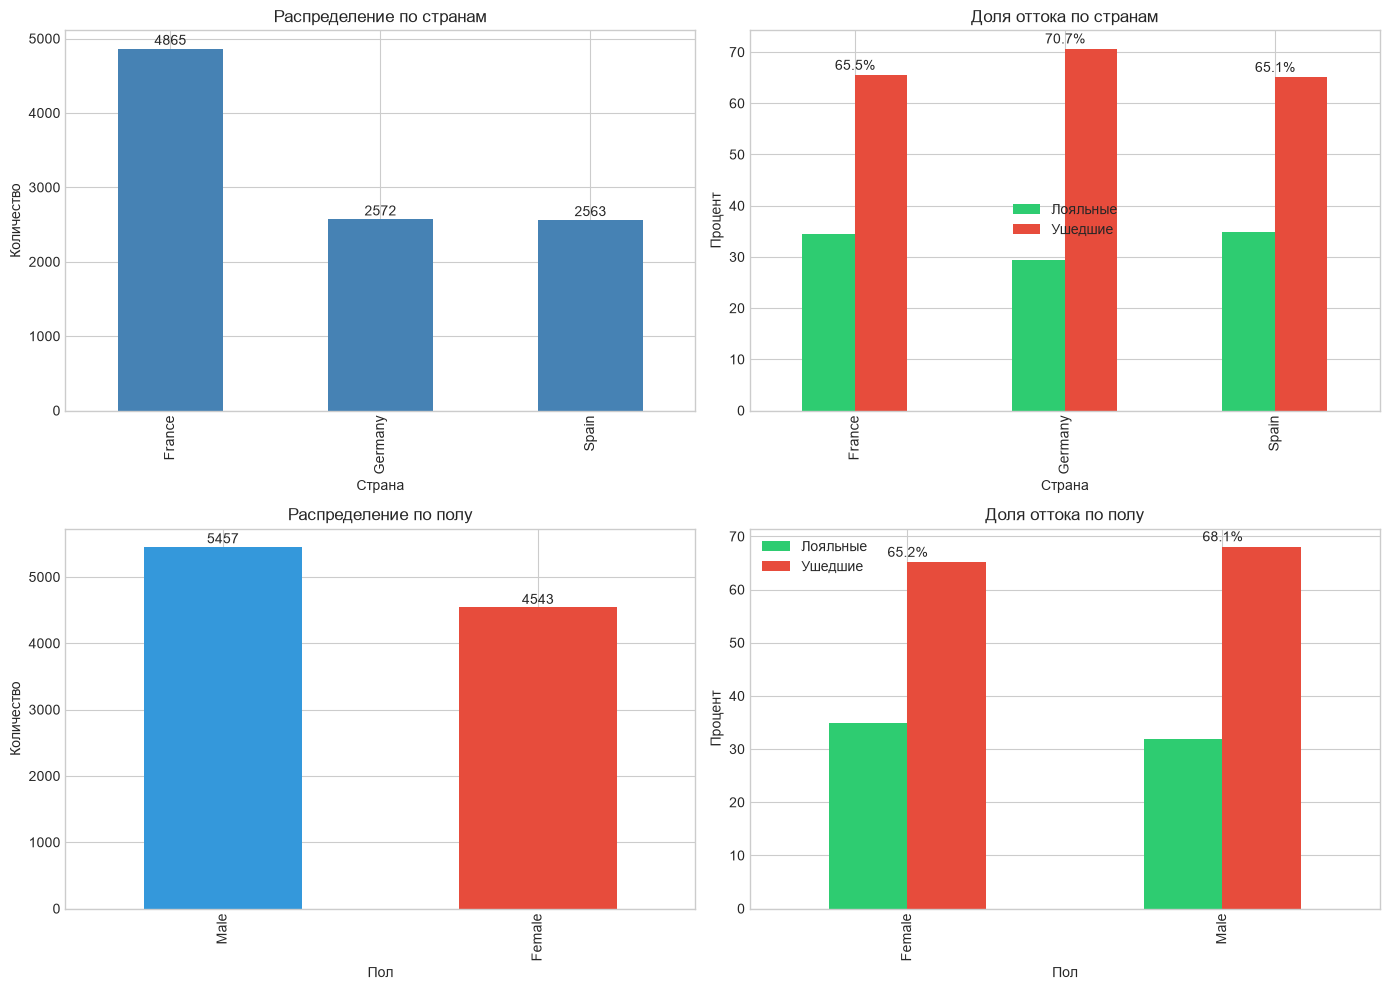

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Страны
df['Geography'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Распределение по странам')
axes[0, 0].set_xlabel('Страна')
axes[0, 0].set_ylabel('Количество')
for i, v in enumerate(df['Geography'].value_counts().values):
    axes[0, 0].text(i, v + 50, str(v), ha='center')

# Отток по странам
geo_exited = pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100
geo_exited.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Доля оттока по странам')
axes[0, 1].set_xlabel('Страна')
axes[0, 1].set_ylabel('Процент')
axes[0, 1].legend(['Лояльные', 'Ушедшие'])
for i, v in enumerate(geo_exited[1]):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center')

# Пол
df['Gender'].value_counts().plot(kind='bar', ax=axes[1, 0], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Распределение по полу')
axes[1, 0].set_xlabel('Пол')
axes[1, 0].set_ylabel('Количество')
for i, v in enumerate(df['Gender'].value_counts().values):
    axes[1, 0].text(i, v + 50, str(v), ha='center')

# Отток по полу
gender_exited = pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100
gender_exited.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Доля оттока по полу')
axes[1, 1].set_xlabel('Пол')
axes[1, 1].set_ylabel('Процент')
axes[1, 1].legend(['Лояльные', 'Ушедшие'])
for i, v in enumerate(gender_exited[1]):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# 5. Анализ числовых признаков

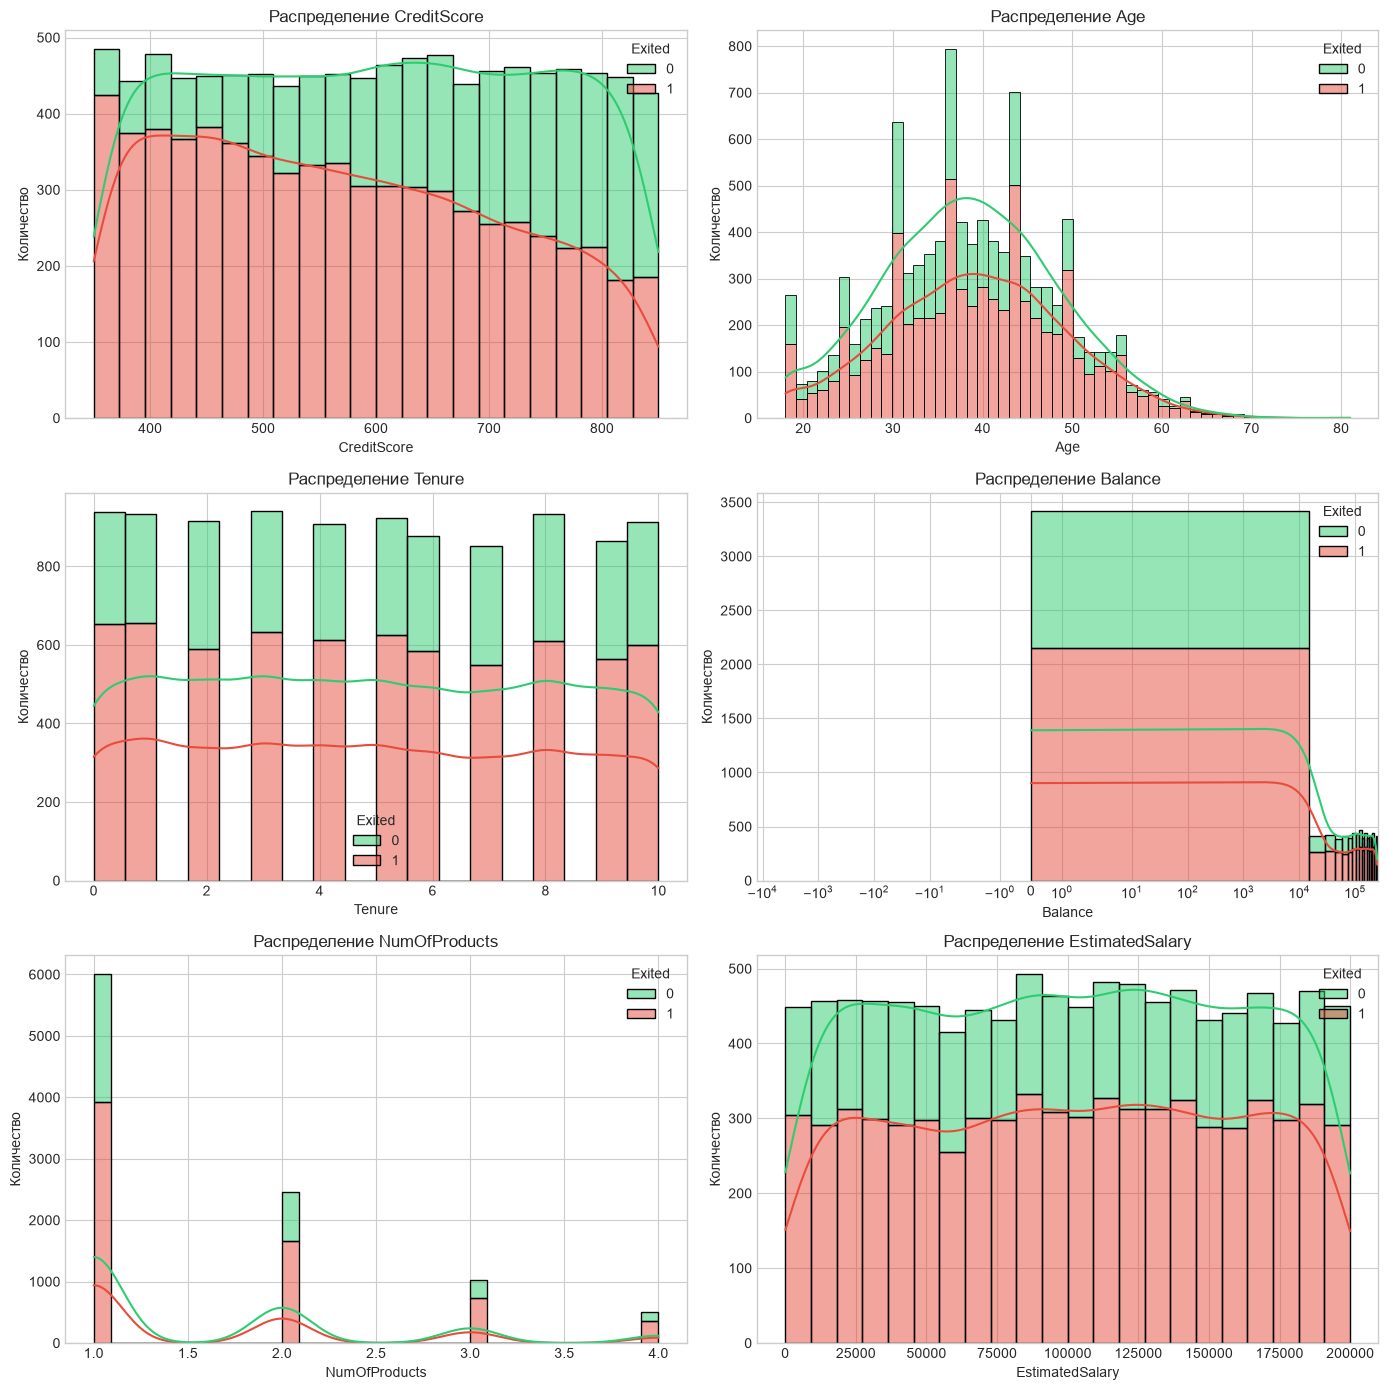

In [5]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='Exited', multiple='stack',
                 ax=axes[i], palette=['#2ecc71', '#e74c3c'], kde=True)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    if col == 'Balance':
        axes[i].set_xscale('symlog')

plt.tight_layout()
plt.show()

# 6. Корреляционный анализ

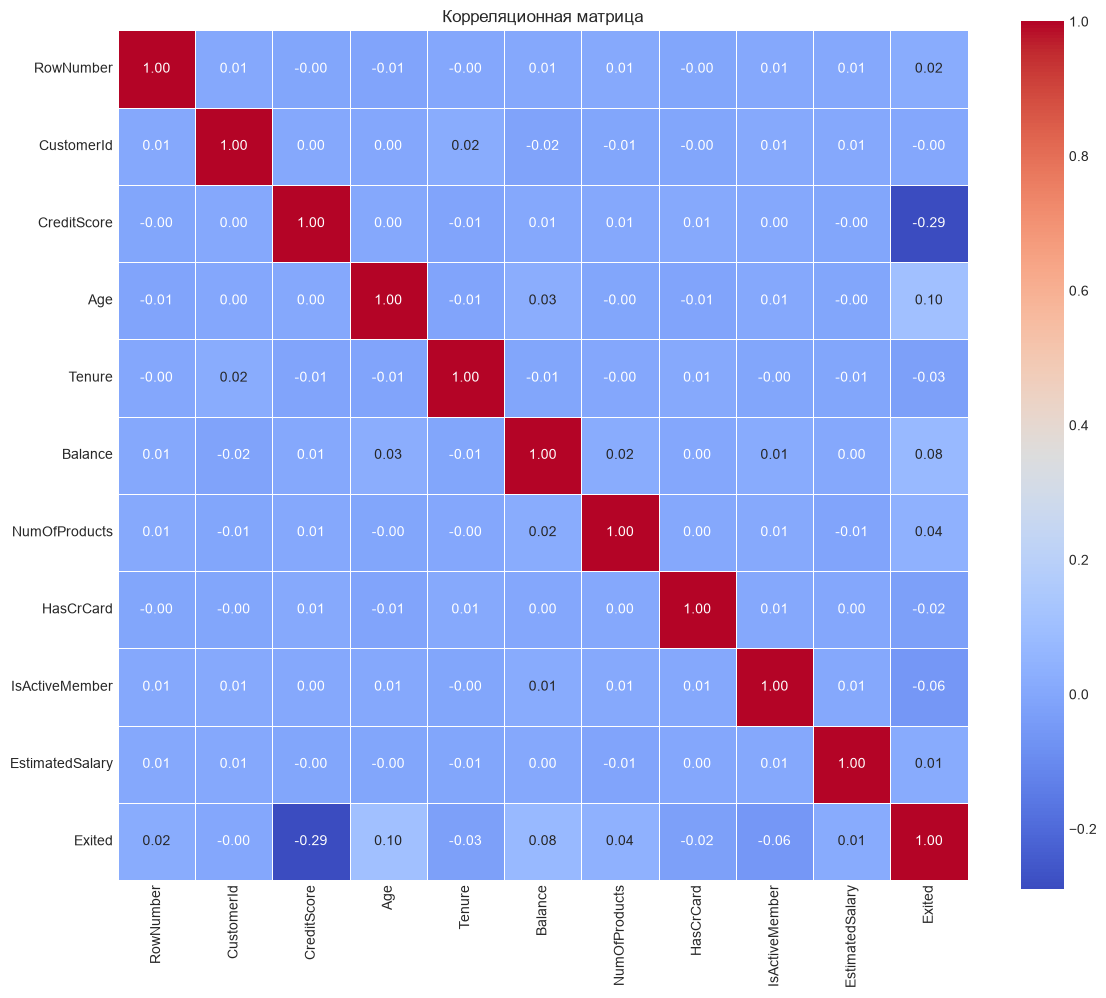


Корреляция с целевой переменной:
Exited             1.000000
Age                0.103806
Balance            0.075930
NumOfProducts      0.041994
RowNumber          0.019338
EstimatedSalary    0.013131
CustomerId        -0.000807
HasCrCard         -0.024326
Tenure            -0.027225
IsActiveMember    -0.055130
CreditScore       -0.289614
Name: Exited, dtype: float64


In [6]:
plt.figure(figsize=(12, 10))
numeric_data = df.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix['Exited'].sort_values(ascending=False)
print("\nКорреляция с целевой переменной:")
print(corr_with_target)

# 7. Предобработка данных

In [7]:
# Удаление неинформативных признаков
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"\nРазмер после удаления: {df_clean.shape}")

# Кодирование категориальных признаков
df_clean['Gender'] = df_clean['Gender'].map({'Female': 0, 'Male': 1})
df_encoded = pd.get_dummies(df_clean, columns=['Geography'], prefix='Geography', drop_first=False)
df_encoded = pd.get_dummies(df_encoded, columns=['Gender'], prefix='Gender', drop_first=True)

print(f"\nПризнаки после кодирования:")
print(df_encoded.columns.tolist())

# Определение X и y
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nМасштабирование выполнено")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

print(f"\nРаспределение в обучающей выборке:")
print(f"Лояльные: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"Ушедшие: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.2f}%)")



Размер после удаления: (10000, 11)

Признаки после кодирования:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_1']

Размер X: (10000, 12)
Размер y: (10000,)

Масштабирование выполнено

Обучающая выборка: (8000, 12)
Тестовая выборка: (2000, 12)

Распределение в обучающей выборке:
Лояльные: 2660 (33.25%)
Ушедшие: 5340 (66.75%)


# 8. Построение модели

In [8]:
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("Модель обучена")

# Прогнозирование
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

Модель обучена


# 9. Оценка качества модели

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*50)
print("Метрики качества модели")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1-score:  {f1:.4f}  ({f1*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f}  ({roc_auc*100:.2f}%)")
print("="*50)

print("\nПодробный отчет:")
print(classification_report(y_test, y_pred, target_names=['Лояльные', 'Ушедшие']))


Метрики качества модели
Accuracy:  0.6450  (64.50%)
Precision: 0.7940  (79.40%)
Recall:    0.6322  (63.22%)
F1-score:  0.7039  (70.39%)
ROC-AUC:   0.7045  (70.45%)

Подробный отчет:
              precision    recall  f1-score   support

    Лояльные       0.48      0.67      0.56       665
     Ушедшие       0.79      0.63      0.70      1335

    accuracy                           0.65      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.69      0.65      0.66      2000



# 10. Матрица ошибок

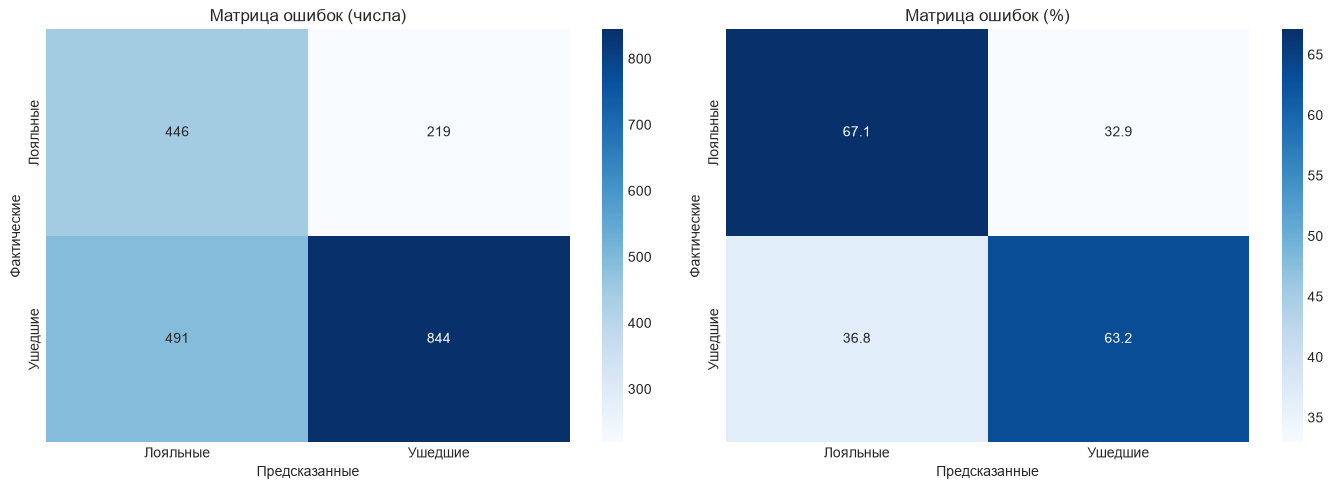


Интерпретация матрицы ошибок:
True Negative (TN)  :  446 - правильно предсказаны лояльные
False Positive (FP) :  219 - лояльные ошибочно отнесены к ушедшим
False Negative (FN) :  491 - ушедшие не выявлены
True Positive (TP)  :  844 - правильно выявлены ушедшие


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Лояльные', 'Ушедшие'],
            yticklabels=['Лояльные', 'Ушедшие'],
            ax=axes[0])
axes[0].set_title('Матрица ошибок (числа)')
axes[0].set_xlabel('Предсказанные')
axes[0].set_ylabel('Фактические')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Лояльные', 'Ушедшие'],
            yticklabels=['Лояльные', 'Ушедшие'],
            ax=axes[1])
axes[1].set_title('Матрица ошибок (%)')
axes[1].set_xlabel('Предсказанные')
axes[1].set_ylabel('Фактические')

plt.tight_layout()
plt.show()

print("\nИнтерпретация матрицы ошибок:")
print("="*50)
print(f"True Negative (TN)  : {cm[0, 0]:4d} - правильно предсказаны лояльные")
print(f"False Positive (FP) : {cm[0, 1]:4d} - лояльные ошибочно отнесены к ушедшим")
print(f"False Negative (FN) : {cm[1, 0]:4d} - ушедшие не выявлены")
print(f"True Positive (TP)  : {cm[1, 1]:4d} - правильно выявлены ушедшие")
print("="*50)


# 11. ROC-кривая

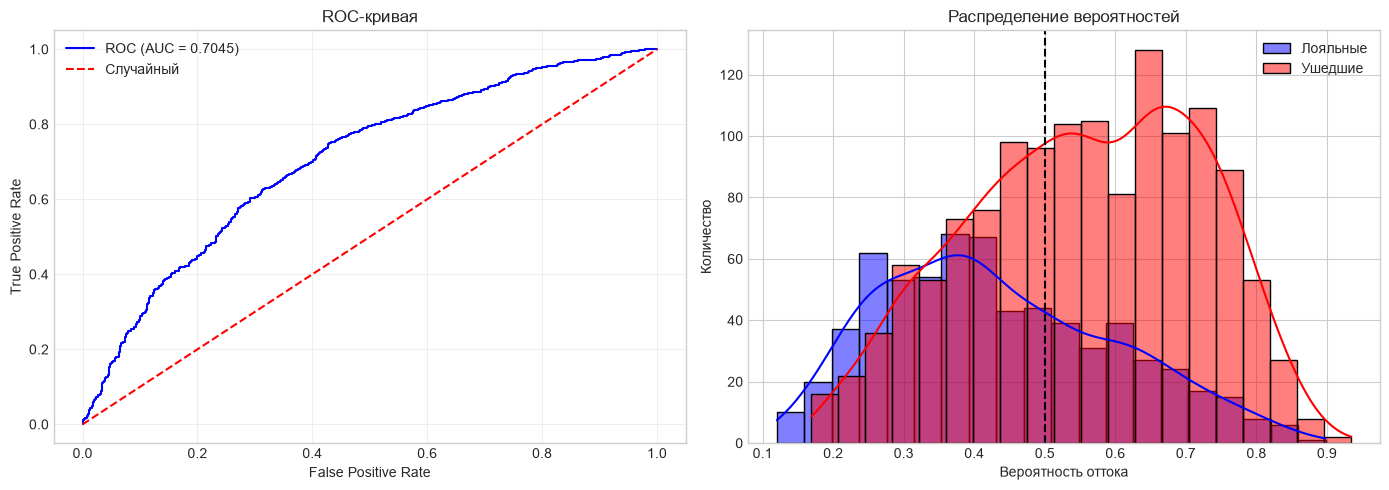

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='blue', label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайный')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(y_pred_proba[y_test == 0], color='blue', label='Лояльные',
             kde=True, ax=axes[1], bins=20, alpha=0.5)
sns.histplot(y_pred_proba[y_test == 1], color='red', label='Ушедшие',
             kde=True, ax=axes[1], bins=20, alpha=0.5)
axes[1].set_xlabel('Вероятность оттока')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение вероятностей')
axes[1].legend()
axes[1].axvline(x=0.5, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# 12. Анализ коэффициентов модели


Важность признаков:
          Признак  Коэффициент          Влияние
              Age     0.238344 Увеличивает риск
          Balance     0.178557 Увеличивает риск
    NumOfProducts     0.108675 Увеличивает риск
         Gender_1     0.090582 Увеличивает риск
Geography_Germany     0.061520 Увеличивает риск
  EstimatedSalary     0.034890 Увеличивает риск
  Geography_Spain    -0.026636     Снижает риск
 Geography_France    -0.030533     Снижает риск
        HasCrCard    -0.045575     Снижает риск
           Tenure    -0.053867     Снижает риск
   IsActiveMember    -0.141811     Снижает риск
      CreditScore    -0.674256     Снижает риск


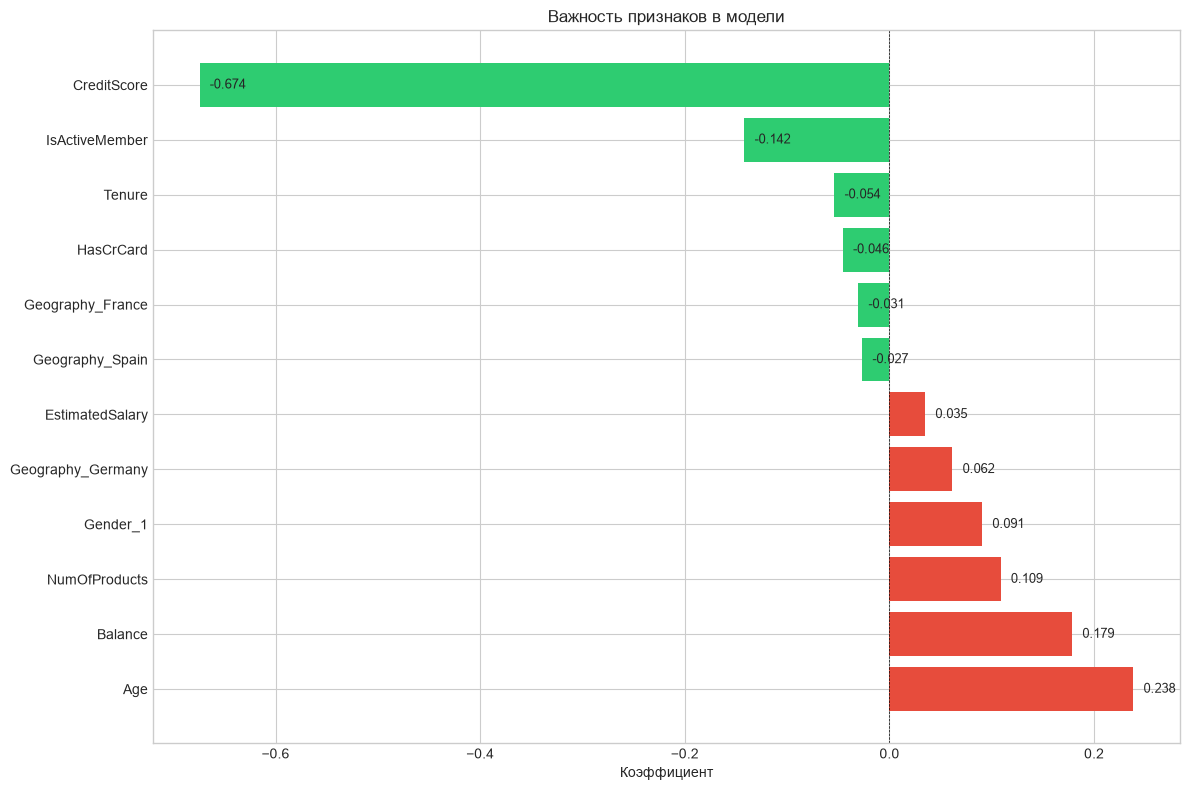

In [12]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Влияние': ['Увеличивает риск' if c > 0 else 'Снижает риск' for c in coefficients]
})

coef_df = coef_df.sort_values('Коэффициент', ascending=False)

print("\nВажность признаков:")
print(coef_df.to_string(index=False))

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Коэффициент']]
plt.barh(coef_df['Признак'], coef_df['Коэффициент'], color=colors)
plt.xlabel('Коэффициент')
plt.title('Важность признаков в модели')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)

for i, v in enumerate(coef_df['Коэффициент']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 13. Выводы и рекомендации

In [13]:
print("\n" + "="*60)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

print("\n📊 ФАКТОРЫ РИСКА (увеличивают отток):")
risk_factors = coef_df[coef_df['Коэффициент'] > 0.1]
for _, row in risk_factors.iterrows():
    print(f"  • {row['Признак']}: {row['Коэффициент']:.3f}")

print("\n🛡️ ЗАЩИТНЫЕ ФАКТОРЫ (снижают отток):")
protect_factors = coef_df[coef_df['Коэффициент'] < -0.1]
for _, row in protect_factors.iterrows():
    print(f"  • {row['Признак']}: {row['Коэффициент']:.3f}")

print("\n💡 РЕКОМЕНДАЦИИ БАНКУ:")
print("  1. Разработать программы для возрастных клиентов (40+)")
print("  2. Поощрять активность клиентов")
print("  3. Анализировать причины оттока клиентов с 3+ продуктами")
print("  4. Улучшить работу с клиентами из Германии")
print("  5. Создать персональные предложения для мужчин")

print("\n📈 КАЧЕСТВО МОДЕЛИ:")
print(f"  • Accuracy:  {accuracy*100:.2f}%")
print(f"  • Recall:    {recall*100:.2f}%")
print(f"  • ROC-AUC:   {roc_auc*100:.2f}%")
print("  • Модель хорошо находит ушедших клиентов")
print("  • Требуется улучшение точности (precision)")

print("\n🚀 НАПРАВЛЕНИЯ УЛУЧШЕНИЯ:")
print("  • Использовать SMOTE для балансировки классов")
print("  • Попробовать Random Forest, XGBoost")
print("  • Добавить новые признаки")
print("="*60)


ВЫВОДЫ И РЕКОМЕНДАЦИИ

📊 ФАКТОРЫ РИСКА (увеличивают отток):
  • Age: 0.238
  • Balance: 0.179
  • NumOfProducts: 0.109

🛡️ ЗАЩИТНЫЕ ФАКТОРЫ (снижают отток):
  • IsActiveMember: -0.142
  • CreditScore: -0.674

💡 РЕКОМЕНДАЦИИ БАНКУ:
  1. Разработать программы для возрастных клиентов (40+)
  2. Поощрять активность клиентов
  3. Анализировать причины оттока клиентов с 3+ продуктами
  4. Улучшить работу с клиентами из Германии
  5. Создать персональные предложения для мужчин

📈 КАЧЕСТВО МОДЕЛИ:
  • Accuracy:  64.50%
  • Recall:    63.22%
  • ROC-AUC:   70.45%
  • Модель хорошо находит ушедших клиентов
  • Требуется улучшение точности (precision)

🚀 НАПРАВЛЕНИЯ УЛУЧШЕНИЯ:
  • Использовать SMOTE для балансировки классов
  • Попробовать Random Forest, XGBoost
  • Добавить новые признаки
